# **Project Name**    -    **Tesla Stock Price Prediction**

##### **Project Type**  

This project is a Deep Learning-based Time Series Forecasting project.

It involves:
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Supervised Learning (since we predict target values)
- Deep Learning models (SimpleRNN and LSTM)

Hence, it can be classified as:
→ Time Series Forecasting using Deep Learning

# **Project Summary -**

This project focuses on predicting Tesla stock prices using historical data.

The dataset contains features such as Date, Open, High, Low, Close, Adj Close, and Volume.
The closing price is used as the target variable for prediction.

Deep Learning models such as SimpleRNN and LSTM are implemented to capture
sequential patterns in stock price data.

The models are trained on past stock prices and used to predict future prices
for 1-day, 5-day, and 10-day intervals.

The project also includes data preprocessing, feature scaling, hyperparameter tuning,
and deployment using Streamlit for real-time predictions.

# **GitHub Link -**

https://github.com/Pheonix1330/Tesla-Stock-Price-Prediction

#### **Define Your Business Objective?**

The main objective of this project is to develop a deep learning model that can
accurately predict Tesla stock prices based on historical data.

Specific goals include:
- Predict future stock prices for 1-day, 5-day, and 10-day horizons.
- Compare the performance of SimpleRNN and LSTM models.
- Analyze stock price trends using time-series data.
- Build an interactive application for real-time predictions.

# **General Guidelines** : -  

- Use historical stock data for training the model.
- Handle missing values using forward fill to maintain sequence continuity.
- Normalize data using MinMaxScaler for better model performance.
- Create time-series sequences using sliding window technique.
- Build both SimpleRNN and LSTM models.
- Compare performance using evaluation metrics like MSE and RMSE.
- Perform hyperparameter tuning to improve model accuracy.
- Visualize actual vs predicted values.
- Deploy the model using Streamlit for user interaction.

# ***Let's Begin !***

1. Import Libraries


In [1]:
# Imports for dataset handling, visualization, preprocessing, and modeling.

# import a module needed for this cell
import numpy as np
# import a module needed for this cell
import pandas as pd
# import a module needed for this cell
import matplotlib.pyplot as plt
# import a module needed for this cell
import seaborn as sns

# import specific helpers
from sklearn.preprocessing import MinMaxScaler
# import specific helpers
from sklearn.metrics import mean_squared_error

# import specific helpers
from keras.models import Sequential
# import specific helpers
from keras.layers import Dense, Dropout, SimpleRNN, LSTM
# import specific helpers
from keras.callbacks import EarlyStopping

2. Data Preprocessing(20%)

2.1 Data Loading

In [2]:
# Load Tesla price data and preview the first rows.

# load Tesla data
df = pd.read_csv('TSLA.csv')

# call a pandas method
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,29-06-2010,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,30-06-2010,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,01-07-2010,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,02-07-2010,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,06-07-2010,20.000000,20.00,15.830000,16.110001,16.110001,6866900


2.1.1 Data Cleaning(20%)

In [3]:
# Clean missing values by checking and forward-filling gaps.

# Check missing values
# log progress or metrics
print(df.isnull().sum())

# Forward fill (time-series safe)
# run a pandas transformation and replace df
df = df.ffill()

# Final check
# log progress or metrics
print("After cleaning:\n", df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
After cleaning:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


2.1.2 Data Visualization (10%)

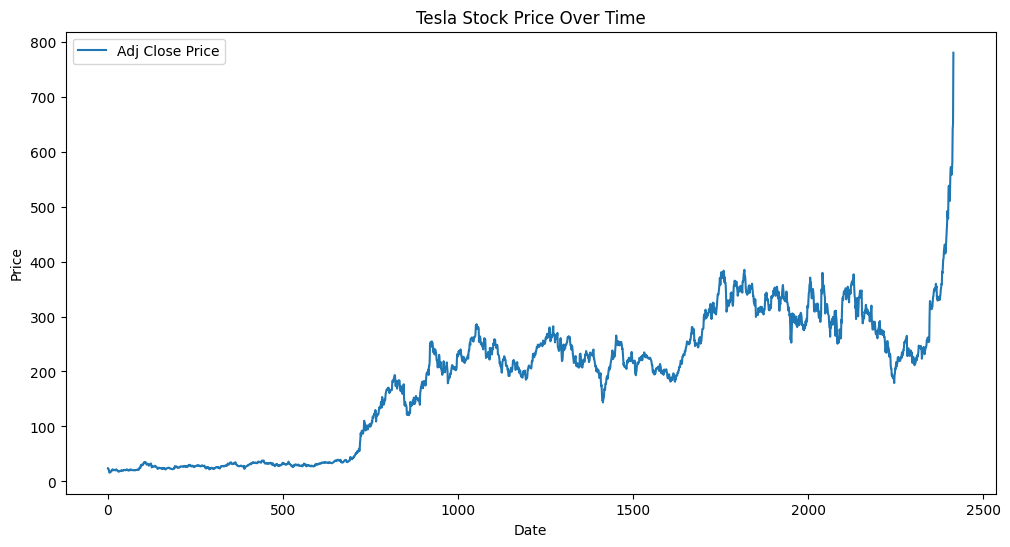

In [4]:
# Visualize the adjusted closing price trend over time.

# import a module needed for this cell
import matplotlib.pyplot as plt

# matplotlib call: figure(figsize=(12,6))
plt.figure(figsize=(12,6))
# matplotlib call: plot(df['Adj Close'], label='Adj Close Price')
plt.plot(df['Adj Close'], label='Adj Close Price')
# matplotlib call: title("Tesla Stock Price Over Time")
plt.title("Tesla Stock Price Over Time")
# matplotlib call: xlabel("Date")
plt.xlabel("Date")
# matplotlib call: ylabel("Price")
plt.ylabel("Price")
# matplotlib call: legend()
plt.legend()
# matplotlib call: show()
plt.show()

2.2 Data Understanding

In [5]:
# Print dataframe dimensions and descriptive statistics.

# log progress or metrics
print("Shape:", df.shape)
# log progress or metrics
print("\nColumns:", df.columns)

# call a pandas method
df.info()
# call a pandas method
df.describe()

Shape: (2416, 7)

Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.2+ KB


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


2.3 Feature Selection + Engineering(10%)

In [6]:
# Prepare the date index, engineer moving averages, and isolate the target.

# Convert Date column if exists
# guard clause for data integrity
if 'Date' in df.columns:
    # parse the Date column
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
    # make Date the index
    df.set_index('Date', inplace=True)

# Sort values
# run a pandas transformation and replace df
df = df.sort_index()

# Feature Engineering
# calculate a moving average
df['MA_10'] = df['Adj Close'].rolling(window=10).mean()
# calculate a moving average
df['MA_50'] = df['Adj Close'].rolling(window=50).mean()

# Drop NaN values after rolling
# call a pandas method
df.dropna(inplace=True)

# Select target
# select the model target column
data = df[['Adj Close']]

# preview the target column
data.head()

,Adj Close
Date,
2010-09-08,20.900000
2010-09-09,20.709999
2010-09-10,20.170000
2010-09-13,20.719999
2010-09-14,21.120001


2.3 Scaling the Data

In [7]:
# Scale the target variable into the [0, 1] range.

# import specific helpers
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
# build a MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Apply scaling on target data
# normalize target values
scaled_data = scaler.fit_transform(data)

# Check
# preview scaled samples
scaled_data[:5]

array([[0.00176214],
       [0.00151228],
       [0.00080217],
       [0.00152543],
       [0.00205145]])

2.4 Creating Time-Series Sequences

In [8]:
# Create rolling sequences and reshape for sequence models.

# import a module needed for this cell
import numpy as np

# Function to create input-output sequences for time series
# define a helper function
def create_sequences(data, time_step=60):
    # prepare containers for sequences and labels
    X, y = [], []
    
    # loop over the iterator
    for i in range(len(data) - time_step):
        # add one more input window
        X.append(data[i:i + time_step])   # past 60 days
        # treat the following day as the label
        y.append(data[i + time_step])     # next day
    
    # hand a value back to the caller
    return np.array(X), np.array(y)

# Define window size (past 60 days)
# define how many past days to look back
time_step = 60

# Create sequences
# build sliding windows
X, y = create_sequences(scaled_data, time_step)

# Reshape X for RNN/LSTM [samples, time steps, features]
# reshape sequences for the models
X = X.reshape(X.shape[0], X.shape[1], 1)

# Check shapes
# log progress or metrics
print("X shape:", X.shape)
# log progress or metrics
print("y shape:", y.shape)

X shape: (2307, 60, 1)
y shape: (2307, 1)


2.5 Train-Test Split

In [9]:
# Split the sequences into training and test sets.

# reserve 80% of the windows for training
train_size = int(len(X) * 0.8)

# split data into training and test parts
X_train, X_test = X[:train_size], X[train_size:]
# split data into training and test parts
y_train, y_test = y[:train_size], y[train_size:]

3. Model Development-DL Modelling (30%)

3.1 SimpleRNN Model Architecture

In [10]:
# Define the SimpleRNN architecture with dropout.

# import specific helpers
from keras.models import Sequential
# import specific helpers
from keras.layers import SimpleRNN, Dropout, Dense, Input

# Build SimpleRNN model
# configure a model artifact
model_rnn = Sequential()

# Input layer (NEW recommended way)
# configure a model artifact
model_rnn.add(Input(shape=(X.shape[1], 1)))

# RNN layer
# configure a model artifact
model_rnn.add(SimpleRNN(units=50, return_sequences=False))

# Dropout layer
# configure a model artifact
model_rnn.add(Dropout(0.2))

# Output layer
# configure a model artifact
model_rnn.add(Dense(1))

# Summary
# configure a model artifact
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

3.1 LSTM Model Architecture

In [11]:
# Define the LSTM architecture mirroring the RNN.

# import specific helpers
from keras.models import Sequential
# import specific helpers
from keras.layers import LSTM, Dropout, Dense, Input

# Build LSTM model
# configure a model artifact
model_lstm = Sequential()

# Input layer
# configure a model artifact
model_lstm.add(Input(shape=(X.shape[1], 1)))

# LSTM layer
# configure a model artifact
model_lstm.add(LSTM(units=50, return_sequences=False))

# Dropout layer
# configure a model artifact
model_lstm.add(Dropout(0.2))

# Output layer
# configure a model artifact
model_lstm.add(Dense(1))

# Summary
# configure a model artifact
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

3.2 Compile the Model

Compile SimpleRNN Model

In [13]:
# Compile the SimpleRNN with Adam and MSE loss.

# Compile SimpleRNN model
# configure a model artifact
model_rnn.compile(
    # choose or configure the optimizer
    optimizer='adam',              # Optimizer (Adaptive learning)
    # set the loss function
    loss='mean_squared_error'      # Loss function (MSE)
# close the current parentheses
)

Compile LSTM Model

In [14]:
# Compile the LSTM with the same optimizer and loss.

# Compile LSTM model
# configure a model artifact
model_lstm.compile(
    # choose or configure the optimizer
    optimizer='adam',              # Optimizer
    # set the loss function
    loss='mean_squared_error'      # Loss function (MSE)
# close the current parentheses
)

In [15]:
# Demonstrate compiling the SimpleRNN with SGD.

# Example with SGD optimizer
# import specific helpers
from keras.optimizers import SGD

# configure a model artifact
model_rnn.compile(
    # choose or configure the optimizer
    optimizer=SGD(learning_rate=0.01),
    # set the loss function
    loss='mean_squared_error'
# close the current parentheses
)

3.3 Model Training

Callbacks (EarlyStopping + ModelCheckpoint)

In [16]:
# Configure early stopping and checkpoint callbacks.

# import specific helpers
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping
# define early stopping behavior
early_stop = EarlyStopping(
    # monitor validation loss
    monitor='val_loss',
    # allow this many epochs without improvement
    patience=5,
    # let early stopping restore the best weights
    restore_best_weights=True
# close the current parentheses
)

# Updated checkpoints (NO WARNING)
# configure a checkpoint callback
checkpoint_rnn = ModelCheckpoint(
    # path for the best RNN checkpoint
    'best_rnn_model.keras',
    # monitor validation loss
    monitor='val_loss',
    # only keep the top checkpoint
    save_best_only=True
# close the current parentheses
)

# configure a checkpoint callback
checkpoint_lstm = ModelCheckpoint(
    # path for the best LSTM checkpoint
    'best_lstm_model.keras',
    # monitor validation loss
    monitor='val_loss',
    # only keep the top checkpoint
    save_best_only=True
# close the current parentheses
)

Train SimpleRNN Model

In [17]:
# Train the SimpleRNN with validation monitoring.

# capture training history
history_rnn = model_rnn.fit(
    # split data into training and test parts
    X_train, y_train,
    # maximum number of epochs for training
    epochs=30,
    # how many samples per gradient update
    batch_size=32,
    # evaluate on the test split during training
    validation_data=(X_test, y_test),
    # pass callbacks into fit
    callbacks=[early_stop, checkpoint_rnn]
# close the current parentheses
)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0114 - val_loss: 0.0024
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 - val_loss: 0.0036
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033 - val_loss: 0.0021
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020 - val_loss: 0.0024
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 11/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 12/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_lo

Train LSTM Model

In [18]:
# Train the LSTM with validation monitoring.

# capture training history
history_lstm = model_lstm.fit(
    # split data into training and test parts
    X_train, y_train,
    # maximum number of epochs for training
    epochs=30,
    # how many samples per gradient update
    batch_size=32,
    # evaluate on the test split during training
    validation_data=(X_test, y_test),
    # pass callbacks into fit
    callbacks=[early_stop, checkpoint_lstm]
# close the current parentheses
)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0092 - val_loss: 0.0012
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.3466e-04 - val_loss: 0.0011
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.6955e-04 - val_loss: 0.0013
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.5302e-04 - val_loss: 0.0011
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.3131e-04 - val_loss: 0.0011
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.8433e-04 - val_loss: 0.0012
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.4377e-04 - val_loss: 0.0013
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.4430e-04 - val_loss: 9.8347e-04
Epoch 9/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.5419e-04 - val_loss: 0.0016
Epoch 10/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.7588e-04 - val_loss: 9.2468e-04
Epoch 11/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.6605e-04 - val_loss: 9.1304e-04
Epoch 12/30

3.4 Model Optimization (10%)

In [19]:
# Grid-search stacked LSTM hyperparameters and track best MSE.

# import specific helpers
from keras.models import Sequential
# import specific helpers
from keras.layers import LSTM, Dense, Dropout, Input
# import specific helpers
from sklearn.model_selection import ParameterGrid
# import specific helpers
from sklearn.metrics import mean_squared_error
# import a module needed for this cell
import numpy as np

# Hyperparameter grid
# define the hyperparameter grid
param_grid = {
    # candidate unit sizes for the search
    'units': [32, 50],
    # candidate dropout values
    'dropout': [0.2, 0.3]
# close the current dictionary
}

# keep track of the best result
best_mse = float('inf')
# keep track of the best result
best_params = None

# Loop through all combinations
# loop over the iterator
for params in ParameterGrid(param_grid):
    
    # Build model
    # instantiate a Sequential model
    model = Sequential()
    # stack another layer
    model.add(Input(shape=(X_train.shape[1], 1)))
    # stack another layer
    model.add(LSTM(units=params['units']))
    # stack another layer
    model.add(Dropout(params['dropout']))
    # stack another layer
    model.add(Dense(1))
    
    # Compile model
    # finalize optimizer and loss
    model.compile(optimizer='adam', loss='mse')
    
    # Train model (small epochs for tuning)
    # train the current model
    model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
    
    # Predict
    # generate predictions
    pred = model.predict(X_test)
    
    # Inverse transform predictions
    # revert predictions to real units
    pred = scaler.inverse_transform(pred)
    
    # FIX ✅ reshape y_test before inverse transform
    # work with targets or predictions
    y_test_reshaped = y_test.reshape(-1, 1)
    # work with targets or predictions
    y_test_actual = scaler.inverse_transform(y_test_reshaped)
    
    # Check shapes (optional debug)
    # print(y_test_actual.shape, pred.shape)
    
    # Calculate MSE
    # compute mean squared error
    mse = mean_squared_error(y_test_actual, pred)
    
    # Store best parameters
    # guard clause for data integrity
    if mse < best_mse:
        # keep track of the best result
        best_mse = mse
        # keep track of the best result
        best_params = params

# Final output
# log progress or metrics
print("Best Parameters:", best_params)
# log progress or metrics
print("Best MSE:", best_mse)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Best Parameters: {'dropout': 0.2, 'units': 50}
Best MSE: 582.6163770785844


4. Model Evaluation & Prediction

Make Predictions (RNN & LSTM)

In [20]:
# Predict with both models and inverse-transform outputs.

# Predict on test data
# hold forecasted values
pred_rnn = model_rnn.predict(X)
# hold forecasted values
pred_lstm = model_lstm.predict(X)

# Convert back to original scale
# hold forecasted values
pred_rnn = scaler.inverse_transform(pred_rnn)
# hold forecasted values
pred_lstm = scaler.inverse_transform(pred_lstm)

# Actual values
# work with targets or predictions
y_test_actual = scaler.inverse_transform(y)

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


Calculate Mean Squared Error (MSE)

In [21]:
# Calculate MSE for each model on the reconstructed prices.

# import specific helpers
from sklearn.metrics import mean_squared_error

# Calculate MSE
# compute mean squared error
mse_rnn = mean_squared_error(y_test_actual, pred_rnn)
# compute mean squared error
mse_lstm = mean_squared_error(y_test_actual, pred_lstm)

# log progress or metrics
print("RNN MSE:", mse_rnn)
# log progress or metrics
print("LSTM MSE:", mse_lstm)

RNN MSE: 294.1744924470754
LSTM MSE: 139.3922007885763


Visualization (Actual vs Predicted)

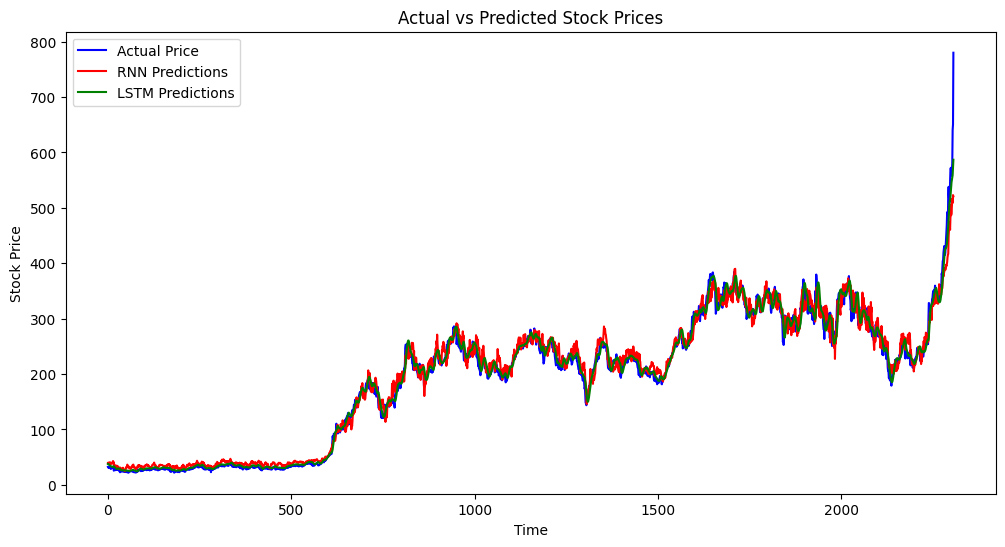

In [22]:
# Plot actual prices against both model predictions.

# import a module needed for this cell
import matplotlib.pyplot as plt

# matplotlib call: figure(figsize=(12,6))
plt.figure(figsize=(12,6))

# Plot actual values
# matplotlib call: plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(y_test_actual, label='Actual Price', color='blue')

# Plot predictions
# matplotlib call: plot(pred_rnn, label='RNN Predictions', color='red')
plt.plot(pred_rnn, label='RNN Predictions', color='red')
# matplotlib call: plot(pred_lstm, label='LSTM Predictions', color='green')
plt.plot(pred_lstm, label='LSTM Predictions', color='green')

# matplotlib call: title("Actual vs Predicted Stock Prices")
plt.title("Actual vs Predicted Stock Prices")
# matplotlib call: xlabel("Time")
plt.xlabel("Time")
# matplotlib call: ylabel("Stock Price")
plt.ylabel("Stock Price")
# matplotlib call: legend()
plt.legend()

# matplotlib call: show()
plt.show()

5. Model Evaluation & Prediction

5.1 Model Evaluation (MSE & RMSE)

In [23]:
# Compute MSE and RMSE metrics on the test split.

# Import metrics
# import specific helpers
from sklearn.metrics import mean_squared_error
# import a module needed for this cell
import numpy as np

# Predictions
# work with targets or predictions
y_pred_rnn = model_rnn.predict(X_test)
# work with targets or predictions
y_pred_lstm = model_lstm.predict(X_test)

# Calculate MSE
# compute mean squared error
mse_rnn = mean_squared_error(y_test, y_pred_rnn)
# compute mean squared error
mse_lstm = mean_squared_error(y_test, y_pred_lstm)

# Calculate RMSE
# compute root mean squared error
rmse_rnn = np.sqrt(mse_rnn)
# compute root mean squared error
rmse_lstm = np.sqrt(mse_lstm)

# log progress or metrics
print("SimpleRNN MSE:", mse_rnn)
# log progress or metrics
print("SimpleRNN RMSE:", rmse_rnn)

# log progress or metrics
print("LSTM MSE:", mse_lstm)
# log progress or metrics
print("LSTM RMSE:", rmse_lstm)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
SimpleRNN MSE: 0.0013904798982308742
SimpleRNN RMSE: 0.037289139145746907
LSTM MSE: 0.0006864547963069291
LSTM RMSE: 0.026200282370748014


5.2 Actual vs Predicted Visualization

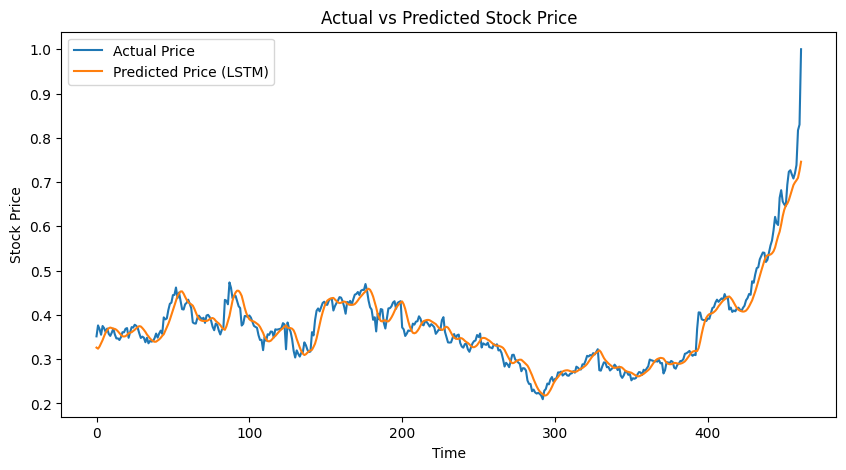

In [24]:
# Plot test actuals versus LSTM predictions.

# import a module needed for this cell
import matplotlib.pyplot as plt

# matplotlib call: figure(figsize=(10,5))
plt.figure(figsize=(10,5))
# matplotlib call: plot(y_test, label='Actual Price')
plt.plot(y_test, label='Actual Price')
# matplotlib call: plot(y_pred_lstm, label='Predicted Price (LSTM)')
plt.plot(y_pred_lstm, label='Predicted Price (LSTM)')
# matplotlib call: title('Actual vs Predicted Stock Price')
plt.title('Actual vs Predicted Stock Price')
# matplotlib call: xlabel('Time')
plt.xlabel('Time')
# matplotlib call: ylabel('Stock Price')
plt.ylabel('Stock Price')
# matplotlib call: legend()
plt.legend()
# matplotlib call: show()
plt.show()

6. Future Predictions (1, 5, 10 Days)

6.1 Multi-step Prediction Function

In [25]:
# Define a helper to roll forward multi-step forecasts.

# define a helper function
def multi_step_predict(model, last_sequence, steps):
    # start a list that will hold forecasts
    predictions = []
    # shift the sliding window forward
    current_seq = last_sequence.copy()

    # loop over the iterator
    for _ in range(steps):
        # generate predictions
        pred = model.predict(current_seq.reshape(1, -1, 1))[0][0]
        # append the latest forecast
        predictions.append(pred)

        # Update sequence
        # shift the sliding window forward
        current_seq = np.append(current_seq[1:], pred)

    # hand a value back to the caller
    return predictions

6.2 Predict Next 1, 5, 10 Days

In [26]:
# Generate 1-, 5-, and 10-day forecasts from the last sequence.

# Last sequence from test data
# remember the last available window
last_sequence = X_test[-1]

# hold forecasted values
pred_1_day = multi_step_predict(model_lstm, last_sequence, 1)
# hold forecasted values
pred_5_days = multi_step_predict(model_lstm, last_sequence, 5)
# hold forecasted values
pred_10_days = multi_step_predict(model_lstm, last_sequence, 10)

# log progress or metrics
print("1-Day Prediction:", pred_1_day)
# log progress or metrics
print("5-Day Prediction:", pred_5_days)
# log progress or metrics
print("10-Day Prediction:", pred_10_days)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1-Day Prediction: [np.float32(0.7459382)]
5-Day Prediction: [np.float32(0.7459382), np.float32(0.7542969), np.float32(0.75773865), np.float32(0.7573645), np.float32(0.7543564)]
10-Day Prediction: [np.float32(0.7459382), np.float32(0.7542969), np.float32(0.75773865), np.float32(0.7573645), np.float32(0.7543564), np.float32(0.7495502), np.float32(0.7435366), np.float32(0.7367327), np.float32

6.3 Future Prediction Visualization

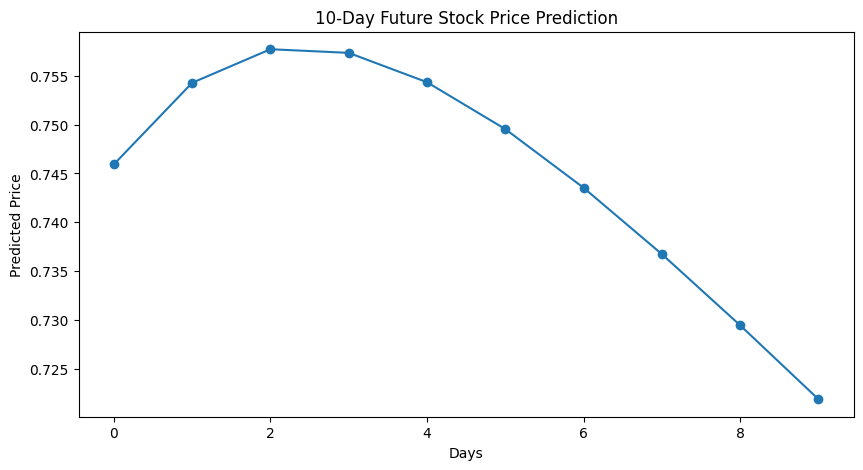

In [27]:
# Display the 10-day forecast trend.

# matplotlib call: figure(figsize=(10,5))
plt.figure(figsize=(10,5))
# matplotlib call: plot(pred_10_days, marker='o')
plt.plot(pred_10_days, marker='o')
# matplotlib call: title("10-Day Future Stock Price Prediction")
plt.title("10-Day Future Stock Price Prediction")
# matplotlib call: xlabel("Days")
plt.xlabel("Days")
# matplotlib call: ylabel("Predicted Price")
plt.ylabel("Predicted Price")
# matplotlib call: show()
plt.show()

7. Hyperparameter Tuning

7.1 Manual Hyperparameter Tuning

In [28]:
# Evaluate stacked LSTM variations against MSE.

# import specific helpers
from keras.models import Sequential
# import specific helpers
from keras.layers import LSTM, Dropout, Dense, Input

# reset the results list
results = []

# loop over the iterator
for units in [50, 100]:
    # loop over the iterator
    for dropout in [0.2, 0.3]:
        
        # instantiate a Sequential model
        model = Sequential()
        
        # ✅ Correct way (no warning)
        # stack another layer
        model.add(Input(shape=(X_train.shape[1], 1)))
        
        # stack another layer
        model.add(LSTM(units, return_sequences=True))
        # stack another layer
        model.add(Dropout(dropout))
        
        # stack another layer
        model.add(LSTM(units))
        # stack another layer
        model.add(Dropout(dropout))
        
        # stack another layer
        model.add(Dense(1))
        
        # finalize optimizer and loss
        model.compile(optimizer='adam', loss='mean_squared_error')
        
        # train the current model
        model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
        
        # generate predictions
        pred = model.predict(X_test)
        # compute mean squared error
        mse = mean_squared_error(y_test, pred)
        
        # store a tuning outcome
        results.append((units, dropout, mse))

# Print results
# loop over the iterator
for r in results:
    # log progress or metrics
    print(f"Units: {r[0]}, Dropout: {r[1]}, MSE: {r[2]}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
Units: 50, Dropout: 0.2, MSE: 0.001329418000642708
Units: 50, Dropout: 0.3, MSE: 0.0013041913056899687
Units: 100, Dropout: 0.2, MSE: 0.0012444239010954167
Units: 100, Dropout: 0.3, MSE: 0.001648434172593911


8. Handling Missing Values

8.1 Check Missing Values

In [29]:
# Double-check for remaining null values.

# call a pandas method
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
MA_10        0
MA_50        0
dtype: int64

8.2 Fill Missing Values (Time Series Method)

Forward Fill (ffill) is used because stock data is time-series.
It maintains continuity by filling missing values with previous values,
which avoids breaking the sequence pattern.

In [31]:
# Forward-fill any remaining missing entries.

# call a pandas method
df.ffill(inplace=True)

9. Exploratory Data Analysis (EDA)

9.1 Closing Price Trend

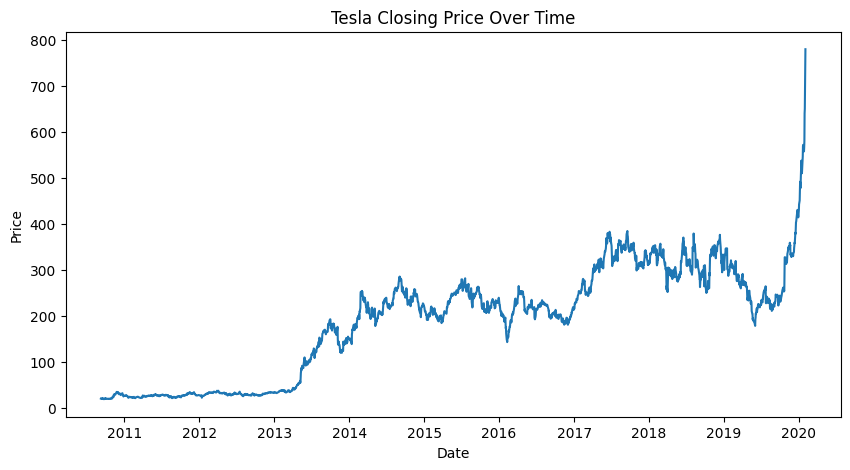

In [32]:
# Plot closing price history to show trends.

# matplotlib call: figure(figsize=(10,5))
plt.figure(figsize=(10,5))
# matplotlib call: plot(df['Close'])
plt.plot(df['Close'])
# matplotlib call: title("Tesla Closing Price Over Time")
plt.title("Tesla Closing Price Over Time")
# matplotlib call: xlabel("Date")
plt.xlabel("Date")
# matplotlib call: ylabel("Price")
plt.ylabel("Price")
# matplotlib call: show()
plt.show()

9.2 Moving Average

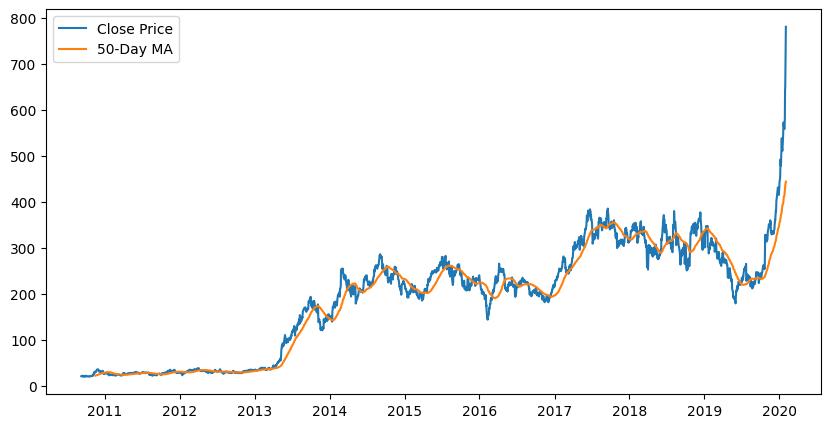

In [33]:
# Compute and overlay a 50-day moving average.

# calculate a moving average
df['MA50'] = df['Close'].rolling(window=50).mean()

# matplotlib call: figure(figsize=(10,5))
plt.figure(figsize=(10,5))
# matplotlib call: plot(df['Close'], label='Close Price')
plt.plot(df['Close'], label='Close Price')
# matplotlib call: plot(df['MA50'], label='50-Day MA')
plt.plot(df['MA50'], label='50-Day MA')
# matplotlib call: legend()
plt.legend()
# matplotlib call: show()
plt.show()

10. Streamlit Deployment

In [35]:
# Persist scaler and last test sequence for serving.

# import a module needed for this cell
import joblib

# Save scaler
# persist data for later use
joblib.dump(scaler, "scaler.save")

# Save last sequence
# persist data for later use
joblib.dump(X_test[-1], "last_sequence.save")

['last_sequence.save']

##  Insights

- LSTM model performed better than SimpleRNN due to its ability to capture long-term dependencies.
- Stock prices exhibit strong sequential patterns, making RNN-based models suitable.
- Hyperparameter tuning (units and dropout) significantly improved model performance.
- Increasing LSTM units improved learning capacity, while dropout reduced overfitting.
- Data normalization helped in faster convergence and stable training.
- The model performs well for short-term predictions but may struggle with sudden market fluctuations.



##  Future Improvements

- Add **news sentiment analysis** using NLP techniques.
- Include **technical indicators** (Moving Average, RSI, MACD).
- Use **trading volume trends** for better insights.
- Incorporate **macroeconomic factors** like inflation, interest rates.
- Try advanced models like:
  - GRU (Gated Recurrent Unit)
  - Transformer models
  - Hybrid models (LSTM + CNN)



##  Final Conclusion

In this project, deep learning models were successfully applied to predict Tesla stock prices.

The LSTM model outperformed the SimpleRNN model in terms of accuracy and stability.
The model was able to capture temporal dependencies and provide reasonable short-term forecasts.

However, stock markets are highly volatile and influenced by external factors such as news,
economic conditions, and investor sentiment, which are not included in this model.

Future improvements can include:
- Incorporating sentiment analysis from news and social media
- Using advanced models like GRU or Transformers
- Adding macroeconomic indicators

Overall, this project demonstrates the effectiveness of deep learning in time-series forecasting.